<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; カスタマーサクセス分析</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">顧客解約の根本原因分析</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">ミッドマーケットB2B SaaS向けリテンションレビューのためのPROC FISHBONE特性要因図</div>
</div>

## エグゼクティブサマリー

本分析は、SaaSの顧客解約率上昇の根本原因を構造化された特性要因図(石川ダイアグラム)として整理する。ミッドマーケットB2Bセグメントの年間解約率は目標の8%に対し約18%に達している。退会アンケート、カスタマーサクセスによるヒアリング、コホート起因分析から得られた20件の根本原因の知見を6つの原因カテゴリに分類し、`PROC FISHBONE`により27ノード(効果1・カテゴリの骨6・副原因20)の図として描画する。

補助的な`PROC MEANS`の内訳は、解約の帰属がどこに集中しているかを示す。**製品(Product)**が最も多くの知見を持ち(5件、影響度合計48.1ポイント)、次いで**価格(Pricing)**(4件、42.3)、**サポート(Support)**(4件、40.2)と続く。1件あたりの*平均*影響度で見ると**競合(Competition)**が最も深刻なカテゴリ(平均11.8)であり、全体で最も影響度の高い単一の知見は**価格(Pricing)**の事前予告なしの更新時価格引き上げ(14.2)である。`PROC SGPLOT`のパレート図はすべての個別原因を順位付けし、経営層がどの骨から着手すべきかを一目で把握できるようにする。この成果物はカスタマーサクセスの四半期リテンションレビューに活用される。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.CHURN_RCA | 退会アンケート分析とCSチームの振り返りから統合した顧客解約の根本原因の知見。各行は1つの原因を表し、そのカテゴリ、裏付けとなる根拠、推定される解約影響割合を含む | 20 |

---

In [1]:
/* --------------------------------------------------------
   顧客解約の根本原因分析(RCA)
   SaaSプラットフォーム、B2Bミッドマーケットセグメント。
   各行:原因カテゴリ、具体的な原因、裏付けとなる
   副原因/根拠、推定される解約影響割合
   (退会アンケートおよびコホート起因分析による)。
   -------------------------------------------------------- */
データ work.churn_rca;
    長さ category $40 cause $300 subcause $300;
    INFILE カード dlm='|' dsd truncover;
    入力 category :$40. cause :$300. subcause :$300. churn_impact_pct;
    カード;
製品|エンタープライズ競合と比較したコア機能のギャップ|退会アンケートの34%で一括エクスポートとAPIレート制限が指摘された|12.4
製品|レポート機能の制限|標準プランにはカスタムダッシュボードビルダーがない|9.8
製品|モバイルアプリがウェブ機能に後れを取っている|モバイル専用ユーザーが完了できない主要ワークフローが3つある|8.2
製品|予告なしの頻繁なUI変更|四半期ごとの再デザインによりパワーユーザーの業務が混乱|7.6
製品|連携マーケットプレイスのギャップ|SalesforceとHubSpotのネイティブコネクタが欠落|10.1
価格|事前予告なしの更新時価格引き上げ|30日前通知でMRRが18%増加|14.2
価格|席数課金モデルがチーム成長に不利に働く|チームが10名から20名に増えるとコストが倍増|11.3
価格|初回割引が更新時に適用されない|初回更新時に価格への驚き(スティッカーショック)が発生|9.7
価格|複数年契約への優遇がない|年間契約の価格が月次契約と同一|7.1
サポート|初回応答時間が24時間を超過|当該プランのベンチマークは4時間|10.8
サポート|週末サポート品質のギャップ|オフショア対応チームに製品知識が不足|9.3
サポート|エンタープライズプラン未満には専任CSMがいない|ミッドマーケット顧客には指名担当者がいない|11.5
サポート|エスカレーション経路が顧客に不明確|解約顧客の38%がエスカレーションの分かりにくさを指摘|8.6
オンボーディング|価値実感までの期間が90日を超過|導入の複雑さが販売前に開示されていない|12.9
オンボーディング|セルフサービス用ドキュメントが古い|最終更新は11か月前|8.1
オンボーディング|新機能のアプリ内ガイドツアーがない|6か月時点での機能採用率が30%未満|9.4
競合|競合他社が30%低価格を提示|主要顧客3社が特定の競合他社を明言|13.1
競合|競合他社が無制限席数プランを提供|成長中のチームにおける席数課金の不利益を解消|10.6
関係性|経営層スポンサーの離任への対応不足|推進者が離任、再エンゲージメントの仕組みがない|11.7
関係性|QBR(四半期ビジネスレビュー)の頻度が年次に低下|18か月前にCSチームのリソースが削減された|9.2
;
実行;



NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   ベースライン:RCAカテゴリ別の解約影響度の集中状況。
   合計は解約がどこに集中するかを示し、最大値は各
   カテゴリ内で最も深刻な原因を示す。
   -------------------------------------------------------- */
処理 平均 データ=work.churn_rca n sum mean MAX maxdec=1;
    分類 category;
    変数 churn_impact_pct;
    見出 category='原因カテゴリ' churn_impact_pct='解約影響度(%)';
    表題 'カテゴリ別 顧客解約RCA:影響度パーセンテージ';
実行;


                                                カテゴリ別 顧客解約RCA:影響度パーセンテージ                                                

                                                  The MEANS Procedure

                                Analysis Variable : churn_impact_pct 解約影響度(%)

        原因カテゴリ                            N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------------------
        オンボーディング                              3           30.4           10.1           12.9
        サポート                                  4           40.2           10.1           11.5
        価格                                    4           42.3           10.6           14.2
        競合                                    2           23.7           11.8           13.1
        製品                                    5           48.1            9.6           12.4
        関係性                                   2           20.9           10.4


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                カテゴリ別 顧客解約RCA:影響度パーセンテージ                                                




NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


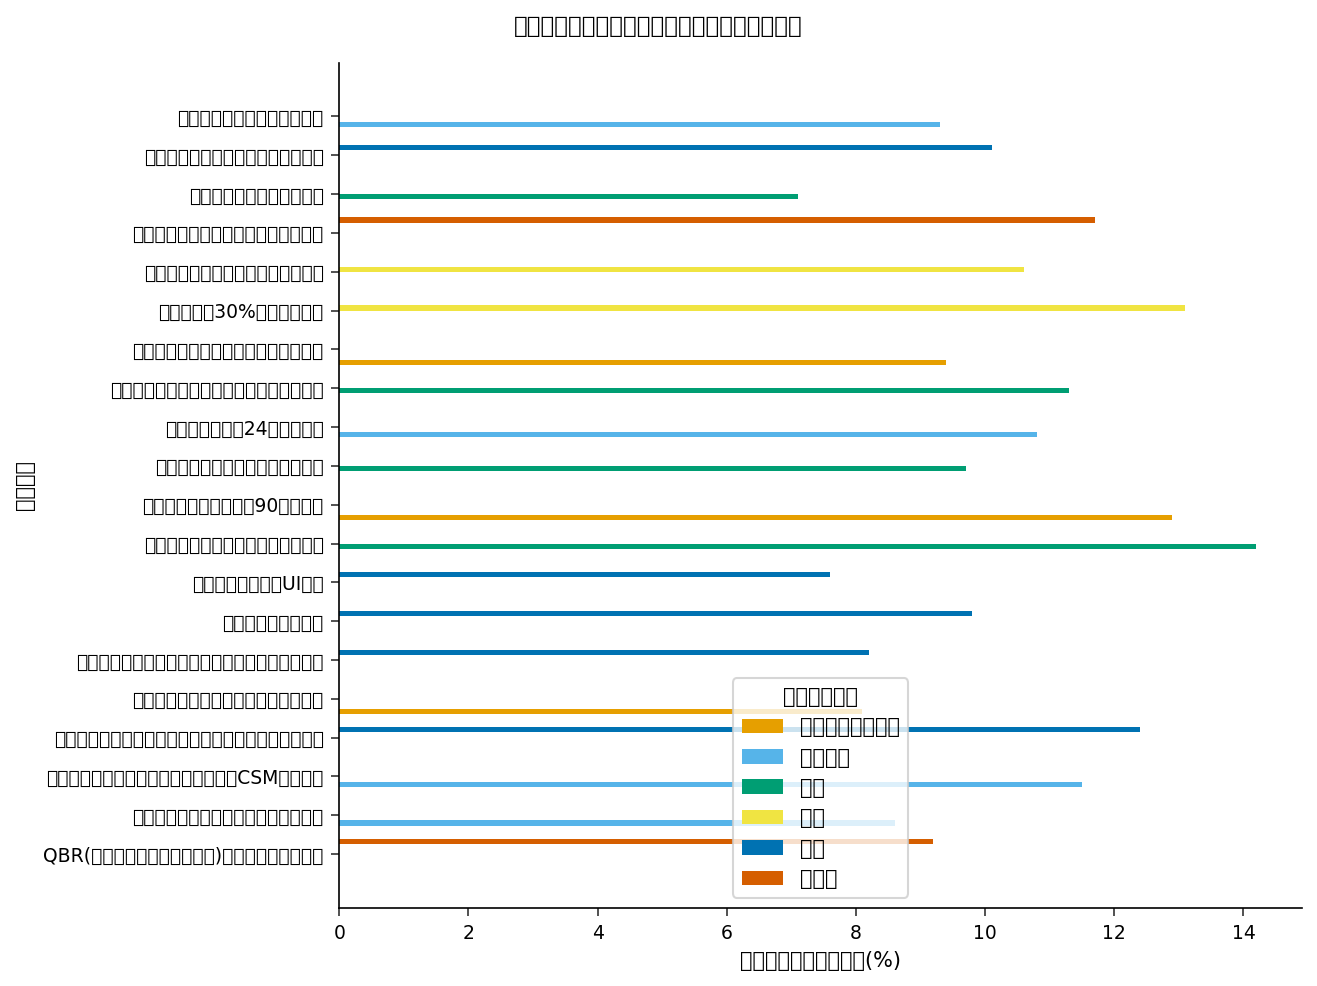

In [3]:
/* --------------------------------------------------------
   パレート図:推定される解約影響度で個々の根本原因を
   順位付けし、カテゴリで色分けする。特性要因図を補完し、
   どの骨が最も重要かを定量化する。
   -------------------------------------------------------- */
処理 並替 データ=work.churn_rca;
    基準 DESCENDING churn_impact_pct;
実行;

処理 SGPLOT データ=work.churn_rca;
    HBAR cause / RESPONSE=churn_impact_pct
        GROUP=category;
    XAXIS 見出='推定される解約影響度(%)';
    YAXIS 見出='根本原因' discreteorder=data;
    keylegend / 表題='原因カテゴリ' position=bottom;
    表題 '推定影響度で順位付けした顧客解約の根本原因';
実行;


---

### 特性要因図(石川ダイアグラム)

`PROC FISHBONE`は`WORK.CHURN_RCA`から直接図を構築する。個々の`category`が中心軸から伸びる大骨となり、個別の`cause`の知見がそのカテゴリの骨からぶら下がる副原因となる。本手続きは以下に完全な特性要因構造――頭部の効果、6本のカテゴリの骨、各骨の下にグループ化されたすべての副原因――を印字し、対応するフィッシュボーン図をディスクに書き出す。上記の順位付けされたパレート図は、これらの骨のうちどれが最も多くの解約に帰属しているかを定量化する対の見方である。

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE:顧客解約の特性要因図。
   図はWORK.CHURN_RCAから直接駆動されるため、6つの
   原因カテゴリとその原因は上記で分析した知見そのもの
   である。CATEGORYが大骨を形成し、CAUSEが各骨の
   副原因としてぶら下がる。
   -------------------------------------------------------- */
処理 fishbone データ=work.churn_rca;
    cause category / subcause=cause;
    effect '顧客解約の増加(年率18% 対 目標8%)';
    表題 '顧客解約 根本原因分析 - ミッドマーケットセグメント';
    footnote '出典:退会アンケート、CSチームヒアリング、コホート起因分析';
実行;


                                                カテゴリ別 顧客解約RCA:影響度パーセンテージ                                                


                    顧客解約 根本原因分析 - ミッドマーケットセグメント
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] 顧客解約の増加(年率18% 対 目標8%)
    [CAUSE] 価格 (top)
      [SUB] 事前予告なしの更新時価格引き上げ
      [SUB] 席数課金モデルがチーム成長に不利に働く
      [SUB] 初回割引が更新時に適用されない
      [SUB] 複数年契約への優遇がない
    [CAUSE] 競合 (top)
      [SUB] 競合他社が30%低価格を提示
      [SUB] 競合他社が無制限席数プランを提供
    [CAUSE] オンボーディング (top)
      [SUB] 価値実感までの期間が90日を超過
      [SUB] 新機能のアプリ内ガイドツアーがない
      [SUB] セルフサービス用ドキュメントが古い
    [CAUSE] 製品 (bottom)
      [SUB] エンタープライズ競合と比較したコア機能のギャップ
      [SUB] 連携マーケットプレイスのギャップ
      [SUB] レポート機能の制限
      [SUB] モバイルアプリがウェブ機能に後れを取っている
      [SUB] 予告なしの頻繁なUI変更
    [CAUSE] 関係性 (bottom)
      [SUB] 経営層スポンサーの離任への対応不足
      [SUB] QBR(四半期ビジネスレビュー)の頻度が年次に低下
    [CAUSE] サポート (bottom)
      [SUB] エンタープライズプラン未満には専任CSMがいない
      [SUB] 初回応答時間が24時間を超過
      [SUB] 週末サポート品質のギャップ
      [SUB] エスカ


NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### 考察

特性要因構造とカテゴリ別`PROC MEANS`の数値は、経営層をごく少数の高レバレッジな施策へと導く。最も影響度の高い2つの単一知見――事前予告なしの**価格(Pricing)**更新時引き上げ(14.2)と、競合が同等機能を30%安く提供しているという**競合(Competition)**の知見(13.1)――はいずれも製品ではなく商業上の課題であり、価格の透明性と競合ポジショニングが最も差し迫った短期的なレバーであることを示唆する。90日を超える価値実感までの期間という**オンボーディング(Onboarding)**の知見(12.9)はサービス側で最大の知見であり、販売前の期待値設定に直結する。

件数で見ると**製品(Product)**が図の中で最多である(20件中5件、影響度合計48.1ポイント)が、個々の知見の大きさ(平均9.6)は**競合(Competition)**(平均11.8)や**価格(Pricing)**(平均10.6)より小さい――製品ギャップの長いリストが自動的に最優先事項になるわけではないことを示す教訓である。**関係性(Relationship)**の骨(経営層スポンサーの離任とQBR頻度低下、合計20.9)は、製品や価格への投資なしにCSチームが今四半期中に実施できるプロセス変更を表しており、測定可能なリテンション改善への最速の道筋を提供する。パレート図の完全な順位付きリストにより、経営層はカテゴリの規模ではなく推定影響度に基づいて施策の順序を決定できる。

---

In [5]:
/* --------------------------------------------------------
   戦略レビュー資料用に解約RCAの知見をエクスポート
   -------------------------------------------------------- */
処理 EXPORT データ=work.churn_rca
    OUTFILE='customer_churn_rca_findings.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密情報
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> 提供
</div>
</div>